# Exploratory Data Analysis (EDA) - Weather & AQI Dataset

## Mục tiêu
Phân tích dữ liệu thời tiết và chất lượng không khí (AQI) để hiểu:
- Cấu trúc và chất lượng dữ liệu
- Phân phối của các biến
- Mối quan hệ giữa thời tiết và chất lượng không khí
- Xu hướng theo thời gian và địa điểm


In [55]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

# Cấu hình
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Hiển thị đầy đủ các cột
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Đã import các thư viện thành công!")


Đã import các thư viện thành công!


In [56]:
# Load dữ liệu
df = pd.read_csv('/Users/vulcanlabs/Master/Data-mining/assignment/data_downloaded/merged_aqi_weather_2018_2024.csv')

print(f"Kích thước dataset: {df.shape}")
print(f"Số dòng: {df.shape[0]:,}")
print(f"Số cột: {df.shape[1]}")
print(f"\nDung lượng bộ nhớ: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Kích thước dataset: (347752, 38)
Số dòng: 347,752
Số cột: 38

Dung lượng bộ nhớ: 137.09 MB


In [57]:
# Xem các dòng đầu tiên
df.head(10)


,time,pm2p5,pm10,latitude,longitude,province,temperature_2m,temperature_80m,temperature_120m,temperature_180m,dewpoint_2m,apparent_temperature,relativehumidity_2m,vapour_pressure_deficit,precipitation_probability,precipitation,rain,showers,snowfall,snow_depth,cloudcover,cloudcover_low,cloudcover_mid,cloudcover_high,visibility,windspeed_10m,windspeed_80m,windspeed_120m,windspeed_180m,winddirection_10m,winddirection_80m,winddirection_120m,winddirection_180m,windgusts_10m,pressure_msl,surface_pressure,soil_temperature_0cm,soil_moisture_0_1cm
0,2018-01-01 00:00:00,72.131221,102.490374,10.5216,105.1259,An_Giang,22.8,NaN,NaN,NaN,21.5,26.7,92,0.22,NaN,0.0,0.0,0.0,0.0,0.0,81,0,3,80,NaN,5.4,NaN,NaN,NaN,48,NaN,NaN,NaN,8.3,1010.7,1010.4,NaN,NaN
1,2018-01-01 00:00:00,43.424697,63.639381,10.5417,107.2429,Ba_Ria_-_Vung_Tau,23.4,NaN,NaN,NaN,17.6,24.8,70,0.87,NaN,0.0,0.0,0.0,0.0,0.0,36,0,2,36,NaN,9.4,NaN,NaN,NaN,67,NaN,NaN,NaN,20.9,1010.3,1006.5,NaN,NaN
2,2018-01-01 00:00:00,203.407003,284.731010,21.2730,106.1946,Bac_Giang,14.2,NaN,NaN,NaN,11.9,14.1,86,0.23,NaN,0.0,0.0,0.0,0.0,0.0,45,9,18,37,NaN,4.4,NaN,NaN,NaN,9,NaN,NaN,NaN,5.4,1020.1,1018.8,NaN,NaN
3,2018-01-01 00:00:00,117.121132,164.634501,22.1470,105.8348,Bac_Kan,13.9,NaN,NaN,NaN,11.4,14.1,85,0.24,NaN,0.0,0.0,0.0,0.0,0.0,53,51,34,0,NaN,1.8,NaN,NaN,NaN,37,NaN,NaN,NaN,6.8,1020.5,1001.2,NaN,NaN
4,2018-01-01 00:00:00,65.328866,94.889581,9.2941,105.7278,Bac_Lieu,24.9,NaN,NaN,NaN,18.6,25.5,68,1.00,NaN,0.0,0.0,0.0,0.0,0.0,65,4,21,59,NaN,17.4,NaN,NaN,NaN,68,NaN,NaN,NaN,33.8,1010.0,1009.5,NaN,NaN
5,2018-01-01 00:00:00,77.376480,110.926023,10.2410,106.3750,Ben_Tre,23.8,NaN,NaN,NaN,20.9,27.3,84,0.47,NaN,0.0,0.0,0.0,0.0,0.0,29,0,13,20,NaN,5.7,NaN,NaN,NaN,35,NaN,NaN,NaN,12.2,1010.4,1009.7,NaN,NaN
6,2018-01-01 00:00:00,12.967782,21.127593,13.7820,109.2197,Binh_Dinh,22.4,NaN,NaN,NaN,19.0,22.9,81,0.50,NaN,0.0,0.0,0.0,0.0,0.0,37,34,1,5,NaN,19.5,NaN,NaN,NaN,19,NaN,NaN,NaN,37.8,1015.5,1012.1,NaN,NaN
7,2018-01-01 00:00:00,54.581139,79.439320,9.1833,105.1524,Ca_Mau,24.4,NaN,NaN,NaN,19.8,26.7,76,0.75,NaN,0.0,0.0,0.0,0.0,0.0,80,2,79,11,NaN,10.1,NaN,NaN,NaN,63,NaN,NaN,NaN,18.7,1010.1,1009.4,NaN,NaN
8,2018-01-01 00:00:00,103.550860,147.223402,10.0452,105.7469,Can_Tho,24.1,NaN,NaN,NaN,21.2,27.3,84,0.48,NaN,0.0,0.0,0.0,0.0,0.0,94,18,50,90,NaN,8.9,NaN,NaN,NaN,58,NaN,NaN,NaN,16.9,1010.2,1009.7,NaN,NaN
9,2018-01-01 00:00:00,17.944331,26.598777,16.0471,108.2068,Da_Nang,21.5,NaN,NaN,NaN,18.1,22.0,81,0.49,NaN,0.3,0.3,0.0,0.0,0.0,92,35,60,80,NaN,17.1,NaN,NaN,NaN,65,NaN,NaN,NaN,28.4,1017.5,1016.6,NaN,NaN


In [58]:
# Thông tin về các cột và kiểu dữ liệu
print("=== THÔNG TIN VỀ DATASET ===\n")
print(df.info())
print("\n=== DANH SÁCH CÁC CỘT ===")
print(df.columns.tolist())


=== THÔNG TIN VỀ DATASET ===



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 347752 entries, 0 to 347751
Data columns (total 38 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   time                       347752 non-null  object 
 1   pm2p5                      347752 non-null  float64
 2   pm10                       347752 non-null  float64
 3   latitude                   347752 non-null  float64
 4   longitude                  347752 non-null  float64
 5   province                   347752 non-null  object 
 6   temperature_2m             347752 non-null  float64
 7   temperature_80m            0 non-null       float64
 8   temperature_120m           0 non-null       float64
 9   temperature_180m           0 non-null       float64
 10  dewpoint_2m                347752 non-null  float64
 11  apparent_temperature       347752 non-null  float64
 12  relativehumidity_2m        347752 non-null  int64  
 13  vapour_pressure_deficit    34

In [59]:
# Kiểm tra giá trị thiếu (missing values)
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Số lượng thiếu': missing_data,
    'Phần trăm thiếu': missing_percent
})
missing_df = missing_df[missing_df['Số lượng thiếu'] > 0].sort_values('Số lượng thiếu', ascending=False)

print("=== CÁC CỘT CÓ GIÁ TRỊ THIẾU ===\n")
if len(missing_df) > 0:
    print(missing_df)
else:
    print("Không có giá trị thiếu trong dataset!")


=== CÁC CỘT CÓ GIÁ TRỊ THIẾU ===

                           Số lượng thiếu  Phần trăm thiếu
temperature_80m                    347752            100.0
temperature_120m                   347752            100.0
temperature_180m                   347752            100.0
precipitation_probability          347752            100.0
visibility                         347752            100.0
windspeed_80m                      347752            100.0
windspeed_120m                     347752            100.0
windspeed_180m                     347752            100.0
winddirection_80m                  347752            100.0
winddirection_120m                 347752            100.0
winddirection_180m                 347752            100.0
soil_temperature_0cm               347752            100.0
soil_moisture_0_1cm                347752            100.0


In [60]:
# Chuyển đổi cột time sang datetime
df['time'] = pd.to_datetime(df['time'])

print(f"Thời gian bắt đầu: {df['time'].min()}")
print(f"Thời gian kết thúc: {df['time'].max()}")
print(f"Khoảng thời gian: {df['time'].max() - df['time'].min()}")
print(f"\nSố lượng các tỉnh/thành phố: {df['province'].nunique()}")
print(f"\nDanh sách các tỉnh/thành phố:")
print(df['province'].unique())


Thời gian bắt đầu: 2018-01-01 00:00:00
Thời gian kết thúc: 2024-12-31 21:00:00
Khoảng thời gian: 2556 days 21:00:00

Số lượng các tỉnh/thành phố: 17

Danh sách các tỉnh/thành phố:
['An_Giang' 'Ba_Ria_-_Vung_Tau' 'Bac_Giang' 'Bac_Kan' 'Bac_Lieu' 'Ben_Tre'
 'Binh_Dinh' 'Ca_Mau' 'Can_Tho' 'Da_Nang' 'Gia_Lai' 'Ha_Noi' 'Hai_Phong'
 'Ho_Chi_Minh' 'Lao_Cai' 'Nghe_An' 'Ninh_Thuan']


In [61]:
# Thống kê mô tả cho các biến số
print("=== THỐNG KÊ MÔ TẢ ===\n")
df.describe()


=== THỐNG KÊ MÔ TẢ ===



,time,pm2p5,pm10,latitude,longitude,temperature_2m,temperature_80m,temperature_120m,temperature_180m,dewpoint_2m,apparent_temperature,relativehumidity_2m,vapour_pressure_deficit,precipitation_probability,precipitation,rain,showers,snowfall,snow_depth,cloudcover,cloudcover_low,cloudcover_mid,cloudcover_high,visibility,windspeed_10m,windspeed_80m,windspeed_120m,windspeed_180m,winddirection_10m,winddirection_80m,winddirection_120m,winddirection_180m,windgusts_10m,pressure_msl,surface_pressure,soil_temperature_0cm,soil_moisture_0_1cm
count,347752,347752.000000,347752.000000,347752.000000,347752.000000,347752.000000,0.0,0.0,0.0,347752.000000,347752.000000,347752.000000,347752.000000,0.0,347752.000000,347752.000000,347752.0,347752.0,347752.0,347752.000000,347752.000000,347752.000000,347752.000000,0.0,347752.000000,0.0,0.0,0.0,347752.000000,0.0,0.0,0.0,347752.000000,347752.000000,347752.000000,0.0,0.0
mean,2021-07-02 10:29:59.999999744,36.754342,51.931029,14.874147,106.469871,25.558669,NaN,NaN,NaN,21.636520,29.334905,80.483968,0.719489,NaN,0.231321,0.231321,0.0,0.0,0.0,72.960584,26.347299,21.944929,56.444417,NaN,9.138948,NaN,NaN,NaN,162.432734,NaN,NaN,NaN,20.577864,1010.433412,1001.776548,NaN,NaN
min,2018-01-01 00:00:00,0.000000,0.000000,9.183300,103.970000,4.200000,NaN,NaN,NaN,-8.600000,0.800000,17.000000,0.000000,NaN,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,0.700000,964.200000,925.300000,NaN,NaN
25%,2019-10-02 05:15:00,17.201738,24.723857,10.521600,105.727800,23.600000,NaN,NaN,NaN,20.200000,26.700000,72.000000,0.220000,NaN,0.000000,0.000000,0.0,0.0,0.0,47.000000,1.000000,1.000000,3.000000,NaN,5.100000,NaN,NaN,NaN,83.000000,NaN,NaN,NaN,11.900000,1007.500000,1002.000000,NaN,NaN
50%,2021-07-02 10:30:00,26.529908,37.551720,13.782000,106.194600,25.900000,NaN,NaN,NaN,23.000000,30.500000,83.000000,0.520000,NaN,0.000000,0.000000,0.0,0.0,0.0,93.000000,10.000000,9.000000,74.000000,NaN,8.100000,NaN,NaN,NaN,146.000000,NaN,NaN,NaN,19.100000,1010.000000,1007.400000,NaN,NaN
75%,2023-04-02 15:45:00,44.169801,62.187201,20.844900,107.242900,28.400000,NaN,NaN,NaN,24.400000,33.200000,92.000000,1.000000,NaN,0.100000,0.100000,0.0,0.0,0.0,100.000000,36.000000,29.000000,99.000000,NaN,12.300000,NaN,NaN,NaN,243.000000,NaN,NaN,NaN,27.400000,1013.000000,1010.300000,NaN,NaN
max,2024-12-31 21:00:00,768.132387,1060.841259,22.480000,109.219700,41.800000,NaN,NaN,NaN,30.300000,47.600000,100.000000,6.690000,NaN,56.900000,56.900000,0.0,0.0,0.0,100.000000,100.000000,100.000000,100.000000,NaN,75.400000,NaN,NaN,NaN,360.000000,NaN,NaN,NaN,141.500000,1034.600000,1033.000000,NaN,NaN
std,NaN,34.411326,48.179143,4.978200,1.422943,4.492112,NaN,NaN,NaN,4.211554,6.084688,14.426670,0.670603,NaN,0.918788,0.918788,0.0,0.0,0.0,34.294318,34.351956,29.735032,42.264194,NaN,5.276953,NaN,NaN,NaN,98.016023,NaN,NaN,NaN,10.762650,5.034578,17.970124,NaN,NaN


## Phân tích các biến chính

### 1. Phân tích PM2.5 và PM10 (Chất lượng không khí)


In [62]:
# Thống kê về PM2.5 và PM10
print("=== THỐNG KÊ PM2.5 ===")
print(df['pm2p5'].describe())
print(f"\nGiá trị min: {df['pm2p5'].min():.2f} μg/m³")
print(f"Giá trị max: {df['pm2p5'].max():.2f} μg/m³")
print(f"Giá trị trung bình: {df['pm2p5'].mean():.2f} μg/m³")
print(f"Giá trị trung vị: {df['pm2p5'].median():.2f} μg/m³")
print(f"Độ lệch chuẩn: {df['pm2p5'].std():.2f} μg/m³")

print("\n=== THỐNG KÊ PM10 ===")
print(df['pm10'].describe())
print(f"\nGiá trị min: {df['pm10'].min():.2f} μg/m³")
print(f"Giá trị max: {df['pm10'].max():.2f} μg/m³")
print(f"Giá trị trung bình: {df['pm10'].mean():.2f} μg/m³")
print(f"Giá trị trung vị: {df['pm10'].median():.2f} μg/m³")
print(f"Độ lệch chuẩn: {df['pm10'].std():.2f} μg/m³")


=== THỐNG KÊ PM2.5 ===
count    347752.000000
mean         36.754342
std          34.411326
min           0.000000
25%          17.201738
50%          26.529908
75%          44.169801
max         768.132387
Name: pm2p5, dtype: float64

Giá trị min: 0.00 μg/m³
Giá trị max: 768.13 μg/m³
Giá trị trung bình: 36.75 μg/m³
Giá trị trung vị: 26.53 μg/m³
Độ lệch chuẩn: 34.41 μg/m³

=== THỐNG KÊ PM10 ===
count    347752.000000
mean         51.931029
std          48.179143
min           0.000000
25%          24.723857
50%          37.551720
75%          62.187201
max        1060.841259
Name: pm10, dtype: float64

Giá trị min: 0.00 μg/m³
Giá trị max: 1060.84 μg/m³
Giá trị trung bình: 51.93 μg/m³
Giá trị trung vị: 37.55 μg/m³
Độ lệch chuẩn: 48.18 μg/m³


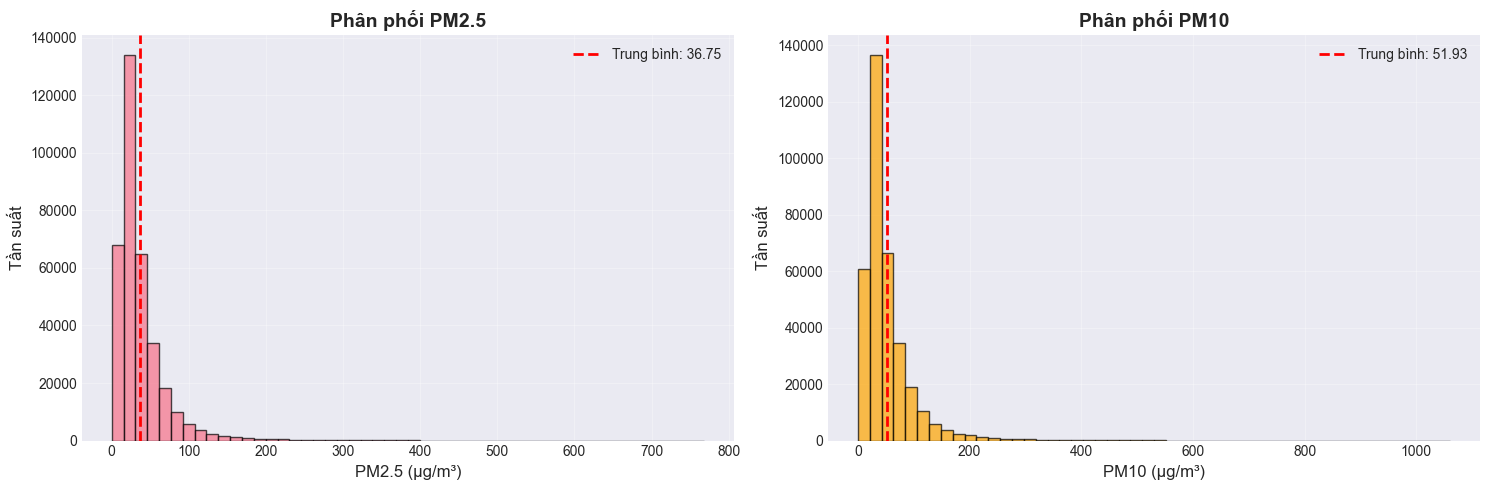

In [63]:
# Vẽ phân phối của PM2.5 và PM10
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# PM2.5
axes[0].hist(df['pm2p5'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Phân phối PM2.5', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PM2.5 (μg/m³)', fontsize=12)
axes[0].set_ylabel('Tần suất', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(df['pm2p5'].mean(), color='red', linestyle='--', linewidth=2, label=f'Trung bình: {df["pm2p5"].mean():.2f}')
axes[0].legend()

# PM10
axes[1].hist(df['pm10'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Phân phối PM10', fontsize=14, fontweight='bold')
axes[1].set_xlabel('PM10 (μg/m³)', fontsize=12)
axes[1].set_ylabel('Tần suất', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].axvline(df['pm10'].mean(), color='red', linestyle='--', linewidth=2, label=f'Trung bình: {df["pm10"].mean():.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()


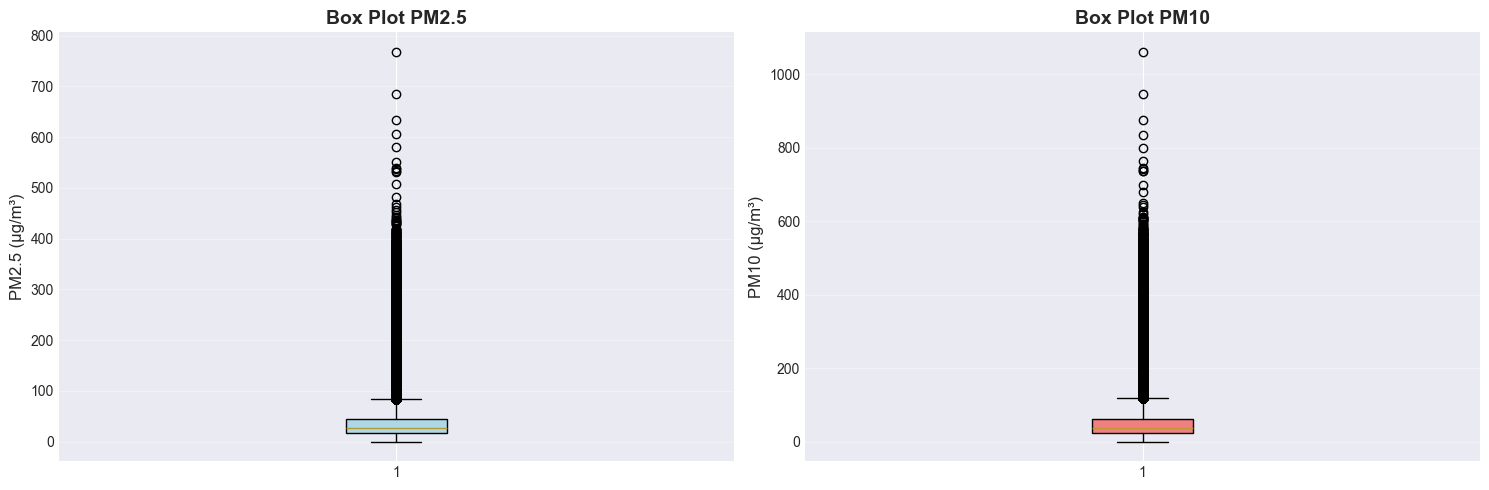

In [64]:
# Box plot để xem outliers
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# PM2.5
bp1 = axes[0].boxplot(df['pm2p5'], vert=True, patch_artist=True)
bp1['boxes'][0].set_facecolor('lightblue')
axes[0].set_title('Box Plot PM2.5', fontsize=14, fontweight='bold')
axes[0].set_ylabel('PM2.5 (μg/m³)', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')

# PM10
bp2 = axes[1].boxplot(df['pm10'], vert=True, patch_artist=True)
bp2['boxes'][0].set_facecolor('lightcoral')
axes[1].set_title('Box Plot PM10', fontsize=14, fontweight='bold')
axes[1].set_ylabel('PM10 (μg/m³)', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


### 2. Phân tích theo Tỉnh/Thành phố


In [65]:
# Số lượng quan sát theo từng tỉnh/thành phố
province_counts = df['province'].value_counts()
print("=== SỐ LƯỢNG QUAN SÁT THEO TỈNH/THÀNH PHỐ ===\n")
print(province_counts)


=== SỐ LƯỢNG QUAN SÁT THEO TỈNH/THÀNH PHỐ ===

province
An_Giang             20456
Ba_Ria_-_Vung_Tau    20456
Bac_Giang            20456
Bac_Kan              20456
Bac_Lieu             20456
Ben_Tre              20456
Binh_Dinh            20456
Ca_Mau               20456
Can_Tho              20456
Da_Nang              20456
Gia_Lai              20456
Ha_Noi               20456
Hai_Phong            20456
Ho_Chi_Minh          20456
Lao_Cai              20456
Nghe_An              20456
Ninh_Thuan           20456
Name: count, dtype: int64


In [66]:
# PM2.5 và PM10 trung bình theo tỉnh/thành phố
province_aqi = df.groupby('province').agg({
    'pm2p5': ['mean', 'median', 'std', 'min', 'max'],
    'pm10': ['mean', 'median', 'std', 'min', 'max']
}).round(2)

print("=== PM2.5 VÀ PM10 THEO TỈNH/THÀNH PHỐ (đơn vị: μg/m³) ===\n")
province_aqi


=== PM2.5 VÀ PM10 THEO TỈNH/THÀNH PHỐ (đơn vị: μg/m³) ===



pm2p5                                pm10                \
                    mean median    std   min     max    mean median    std   
province                                                                     
An_Giang           36.39  30.97  20.54  0.58  143.49   51.31  43.53  28.89   
Ba_Ria_-_Vung_Tau  26.89  24.84  12.54  0.51  136.58   38.27  35.42  17.50   
Bac_Giang          67.56  51.76  49.73  2.91  430.71   94.89  72.65  69.86   
Bac_Kan            49.74  40.70  32.78  0.77  355.99   69.78  57.04  45.95   
Bac_Lieu           28.33  24.04  15.89  1.95  132.04   40.40  34.27  22.35   
Ben_Tre            34.66  30.25  17.14  2.54  161.19   49.07  42.78  24.15   
Binh_Dinh          15.85  14.73   7.66  0.00   79.37   23.15  21.74  10.84   
Ca_Mau             21.73  19.58  10.18  1.18  102.56   31.09  28.02  14.46   
Can_Tho            44.08  35.49  27.56  1.53  216.62   62.32  50.14  38.80   
Da_Nang            20.28  17.79  12.06  0.00  221.20   29.05  25.67  16.88   
Gia_Lai            18.66  15.23  15.09  0.00  257.16   26.52  21.82  20.99   
Ha_Noi             88.50  65.35  69.34  4.66  482.43  124.38  91.80  97.60   
Hai_Phong          50.34  39.77  36.19  1.35  389.09   70.76  55.98  50.59   
Ho_Chi_Minh        36.57  32.60  17.66  1.81  146.53   51.67  45.95  24.85   
Lao_Cai            30.27  25.24  21.40  0.04  295.40   42.29  35.30  29.71   
Nghe_An            37.57  28.87  36.50  0.00  768.13   52.55  40.39  50.55   
Ninh_Thuan         17.39  16.66   7.61  0.02   77.33   25.31  24.52  10.54   

                                  
                    min      max  
province                          
An_Giang           0.85   202.58  
Ba_Ria_-_Vung_Tau  0.89   190.27  
Bac_Giang          4.10   600.69  
Bac_Kan            1.08   495.78  
Bac_Lieu           2.85   184.30  
Ben_Tre            3.68   224.11  
Binh_Dinh          0.00   112.39  
Ca_Mau             1.74   144.51  
Can_Tho            2.18   306.16  
Da_Nang            0.00   309.00  
Gia_Lai            0.00   357.85  
Ha_Noi             6.52   680.48  
Hai_Phong          1.99   541.19  
Ho_Chi_Minh        2.59   203.80  
Lao_Cai            0.05   408.45  
Nghe_An            0.00  1060.84  
Ninh_Thuan         0.03   109.16

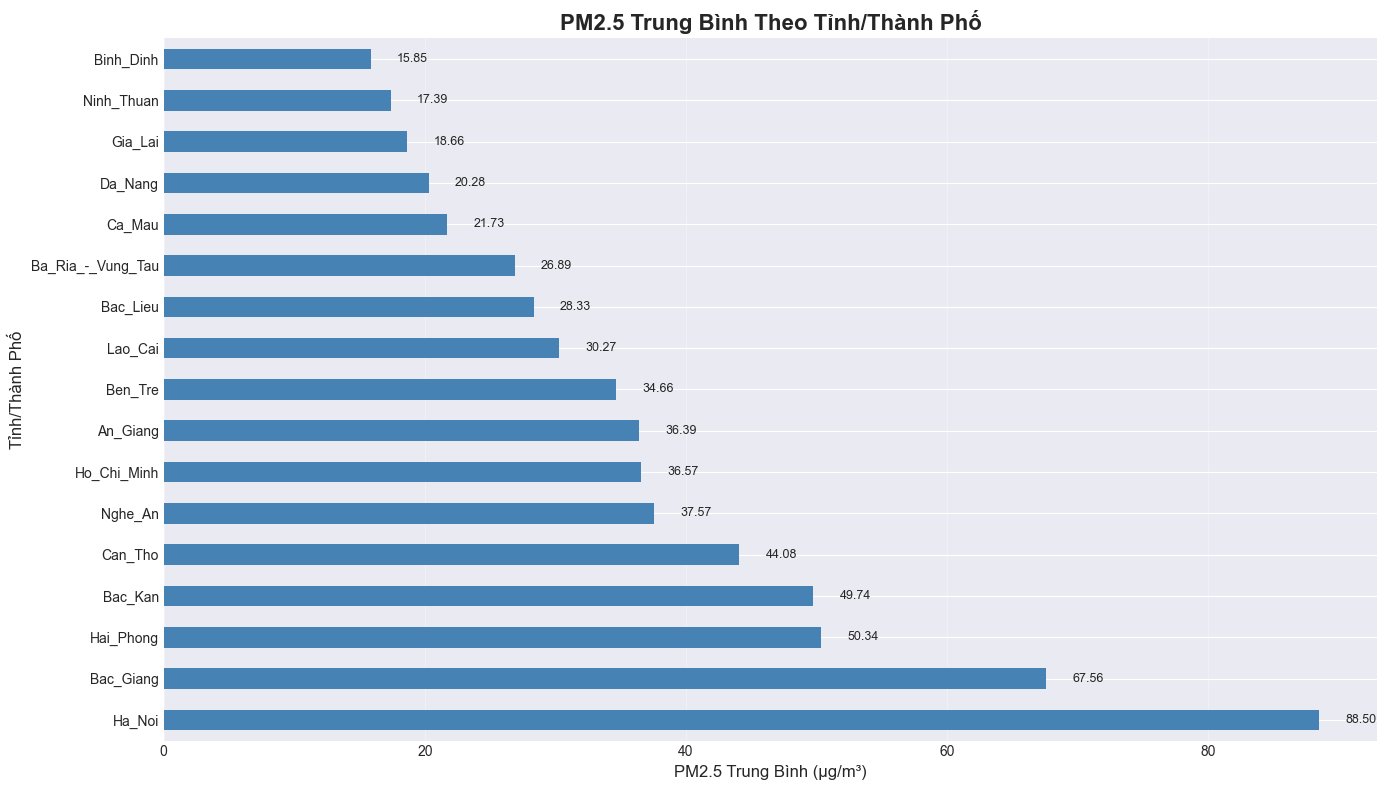

In [67]:
# Vẽ biểu đồ PM2.5 trung bình theo tỉnh/thành phố
province_pm25 = df.groupby('province')['pm2p5'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 8))
bars = province_pm25.plot(kind='barh', color='steelblue')
plt.title('PM2.5 Trung Bình Theo Tỉnh/Thành Phố', fontsize=16, fontweight='bold')
plt.xlabel('PM2.5 Trung Bình (μg/m³)', fontsize=12)
plt.ylabel('Tỉnh/Thành Phố', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')

# Thêm giá trị trên mỗi thanh
for i, (idx, val) in enumerate(province_pm25.items()):
    plt.text(val + 2, i, f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


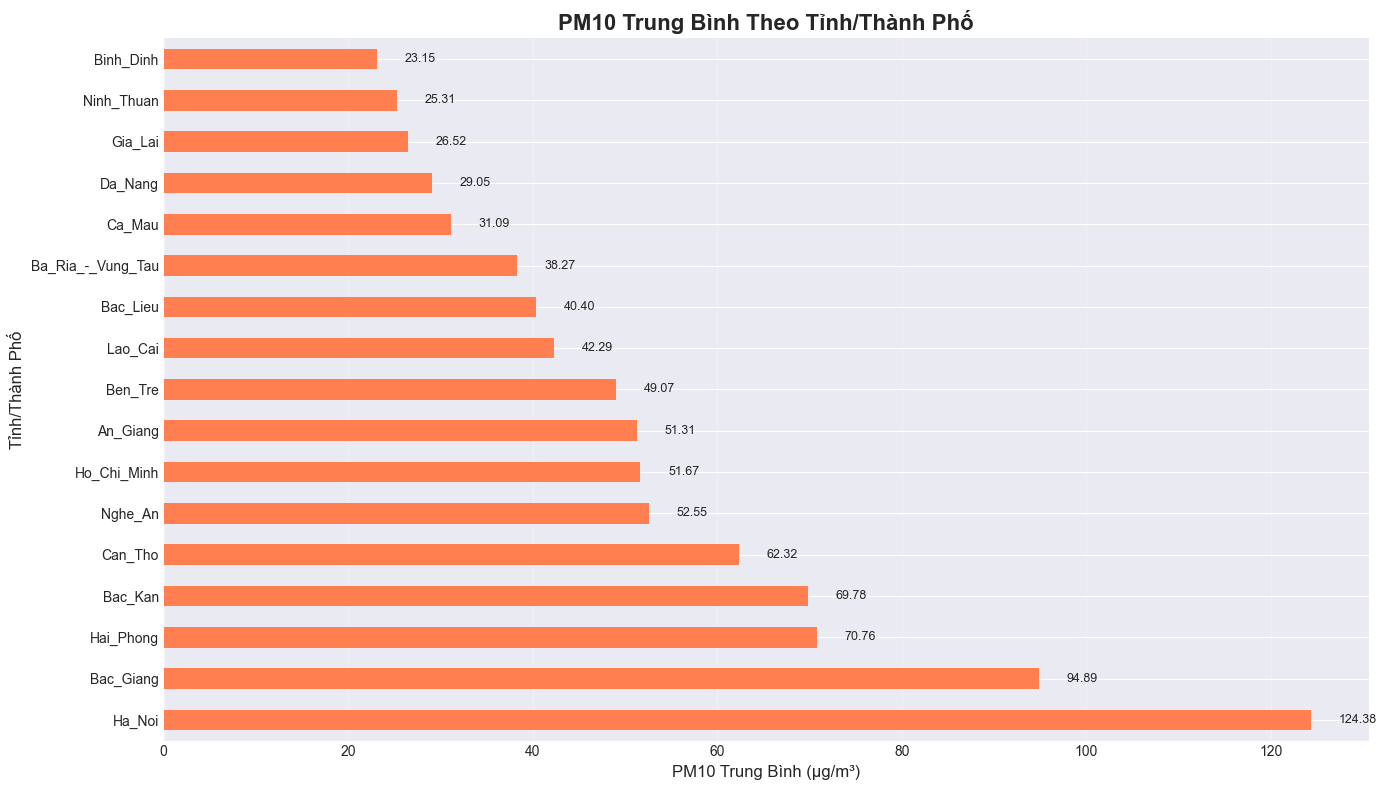

In [68]:
# Vẽ biểu đồ PM10 trung bình theo tỉnh/thành phố
province_pm10 = df.groupby('province')['pm10'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 8))
bars = province_pm10.plot(kind='barh', color='coral')
plt.title('PM10 Trung Bình Theo Tỉnh/Thành Phố', fontsize=16, fontweight='bold')
plt.xlabel('PM10 Trung Bình (μg/m³)', fontsize=12)
plt.ylabel('Tỉnh/Thành Phố', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')

# Thêm giá trị trên mỗi thanh
for i, (idx, val) in enumerate(province_pm10.items()):
    plt.text(val + 3, i, f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


### 3. Phân tích theo Thời gian


In [69]:
# Tạo các cột thời gian để phân tích
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df['day'] = df['time'].dt.day
df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.day_name()

print("=== PHÂN TÍCH THEO THỜI GIAN ===\n")
print(f"Năm: {df['year'].min()} - {df['year'].max()}")
print(f"Tháng: {df['month'].min()} - {df['month'].max()}")
print(f"Giờ trong ngày: {df['hour'].min()} - {df['hour'].max()}")


=== PHÂN TÍCH THEO THỜI GIAN ===

Năm: 2018 - 2024
Tháng: 1 - 12
Giờ trong ngày: 0 - 21


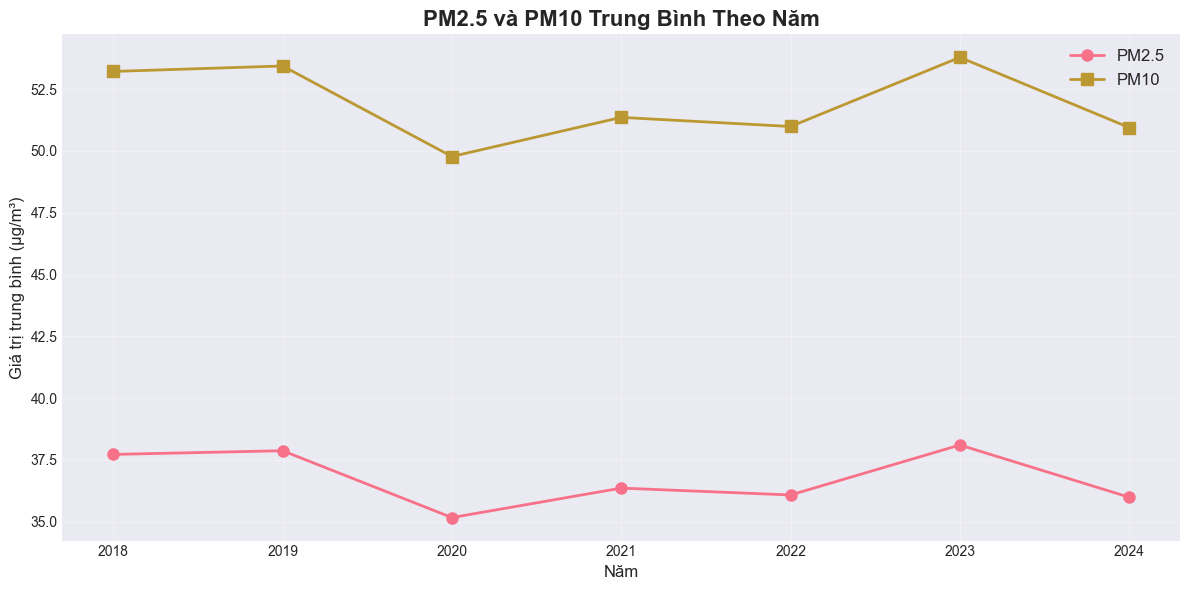

In [70]:
# PM2.5 và PM10 trung bình theo năm
yearly_aqi = df.groupby('year').agg({
    'pm2p5': 'mean',
    'pm10': 'mean'
})

fig, ax = plt.subplots(figsize=(12, 6))
x = yearly_aqi.index
ax.plot(x, yearly_aqi['pm2p5'], marker='o', label='PM2.5', linewidth=2, markersize=8)
ax.plot(x, yearly_aqi['pm10'], marker='s', label='PM10', linewidth=2, markersize=8)
ax.set_title('PM2.5 và PM10 Trung Bình Theo Năm', fontsize=16, fontweight='bold')
ax.set_xlabel('Năm', fontsize=12)
ax.set_ylabel('Giá trị trung bình (μg/m³)', fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


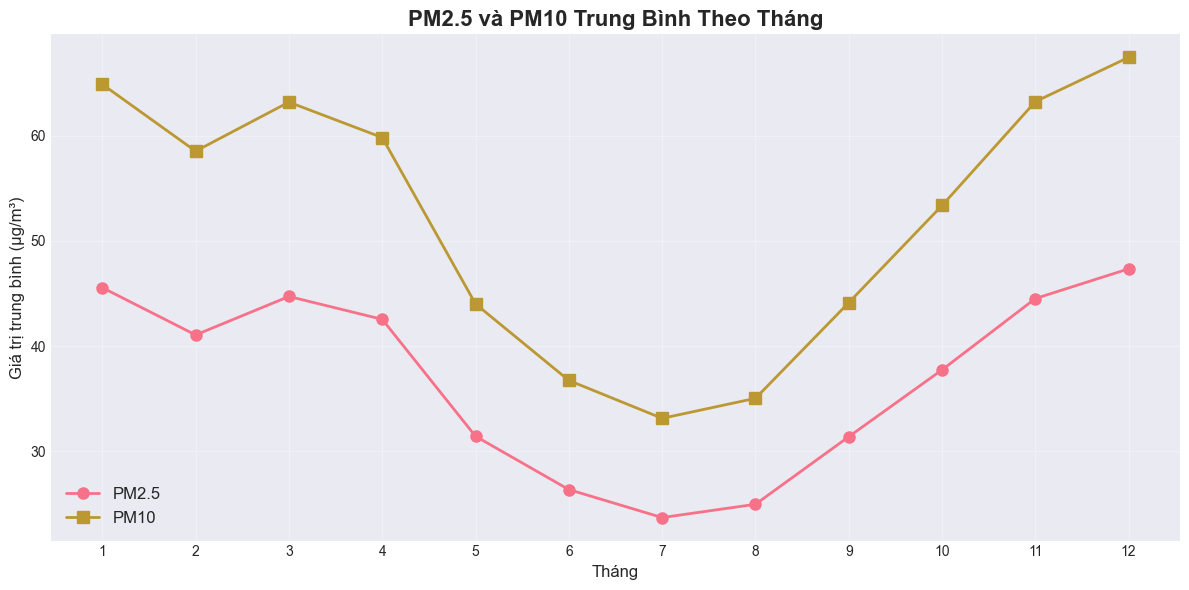

In [71]:
# PM2.5 và PM10 trung bình theo tháng
monthly_aqi = df.groupby('month').agg({
    'pm2p5': 'mean',
    'pm10': 'mean'
})

fig, ax = plt.subplots(figsize=(12, 6))
x = monthly_aqi.index
ax.plot(x, monthly_aqi['pm2p5'], marker='o', label='PM2.5', linewidth=2, markersize=8)
ax.plot(x, monthly_aqi['pm10'], marker='s', label='PM10', linewidth=2, markersize=8)
ax.set_title('PM2.5 và PM10 Trung Bình Theo Tháng', fontsize=16, fontweight='bold')
ax.set_xlabel('Tháng', fontsize=12)
ax.set_ylabel('Giá trị trung bình (μg/m³)', fontsize=12)
ax.set_xticks(range(1, 13))
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


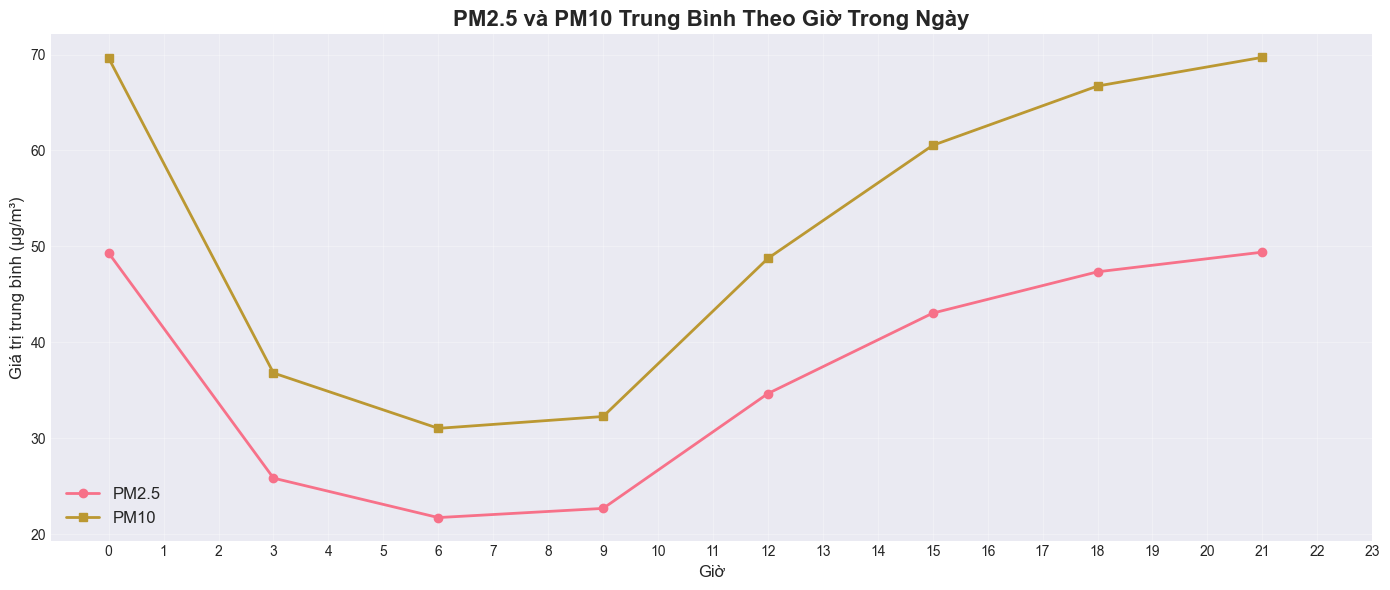

In [72]:
# PM2.5 và PM10 trung bình theo giờ trong ngày
hourly_aqi = df.groupby('hour').agg({
    'pm2p5': 'mean',
    'pm10': 'mean'
})

fig, ax = plt.subplots(figsize=(14, 6))
x = hourly_aqi.index
ax.plot(x, hourly_aqi['pm2p5'], marker='o', label='PM2.5', linewidth=2, markersize=6)
ax.plot(x, hourly_aqi['pm10'], marker='s', label='PM10', linewidth=2, markersize=6)
ax.set_title('PM2.5 và PM10 Trung Bình Theo Giờ Trong Ngày', fontsize=16, fontweight='bold')
ax.set_xlabel('Giờ', fontsize=12)
ax.set_ylabel('Giá trị trung bình (μg/m³)', fontsize=12)
ax.set_xticks(range(0, 24))
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 4. Phân tích các biến thời tiết


In [73]:
# Thống kê các biến thời tiết chính
weather_vars = ['temperature_2m', 'dewpoint_2m', 'apparent_temperature', 
                'relativehumidity_2m', 'windspeed_10m', 'pressure_msl', 
                'precipitation', 'cloudcover']

print("=== THỐNG KÊ CÁC BIẾN THỜI TIẾT ===\n")
df[weather_vars].describe()


=== THỐNG KÊ CÁC BIẾN THỜI TIẾT ===



,temperature_2m,dewpoint_2m,apparent_temperature,relativehumidity_2m,windspeed_10m,pressure_msl,precipitation,cloudcover
count,347752.000000,347752.000000,347752.000000,347752.000000,347752.000000,347752.000000,347752.000000,347752.000000
mean,25.558669,21.636520,29.334905,80.483968,9.138948,1010.433412,0.231321,72.960584
std,4.492112,4.211554,6.084688,14.426670,5.276953,5.034578,0.918788,34.294318
min,4.200000,-8.600000,0.800000,17.000000,0.000000,964.200000,0.000000,0.000000
25%,23.600000,20.200000,26.700000,72.000000,5.100000,1007.500000,0.000000,47.000000
50%,25.900000,23.000000,30.500000,83.000000,8.100000,1010.000000,0.000000,93.000000
75%,28.400000,24.400000,33.200000,92.000000,12.300000,1013.000000,0.100000,100.000000
max,41.800000,30.300000,47.600000,100.000000,75.400000,1034.600000,56.900000,100.000000


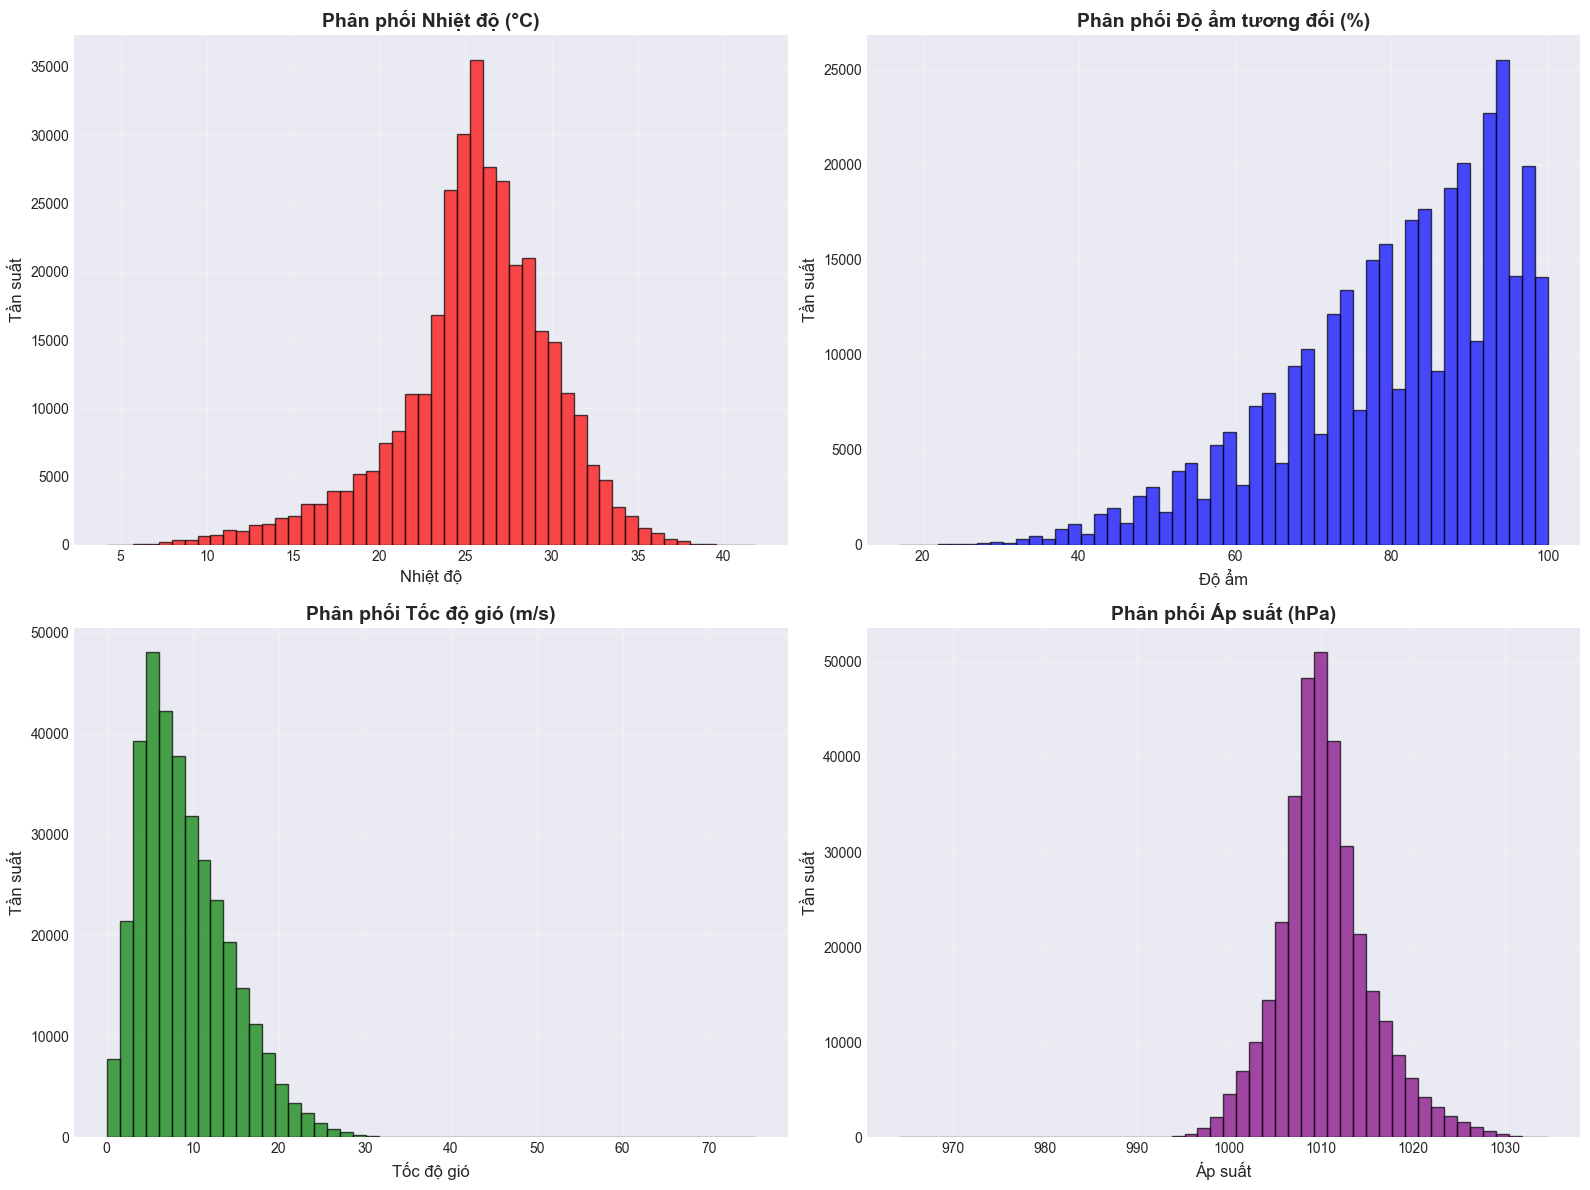

In [74]:
# Vẽ phân phối của một số biến thời tiết quan trọng
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Nhiệt độ
axes[0, 0].hist(df['temperature_2m'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='red')
axes[0, 0].set_title('Phân phối Nhiệt độ (°C)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Nhiệt độ', fontsize=12)
axes[0, 0].set_ylabel('Tần suất', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# Độ ẩm
axes[0, 1].hist(df['relativehumidity_2m'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='blue')
axes[0, 1].set_title('Phân phối Độ ẩm tương đối (%)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Độ ẩm', fontsize=12)
axes[0, 1].set_ylabel('Tần suất', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# Tốc độ gió
axes[1, 0].hist(df['windspeed_10m'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_title('Phân phối Tốc độ gió (m/s)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Tốc độ gió', fontsize=12)
axes[1, 0].set_ylabel('Tần suất', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# Áp suất
axes[1, 1].hist(df['pressure_msl'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_title('Phân phối Áp suất (hPa)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Áp suất', fontsize=12)
axes[1, 1].set_ylabel('Tần suất', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 5. Mối quan hệ giữa Thời tiết và Chất lượng không khí


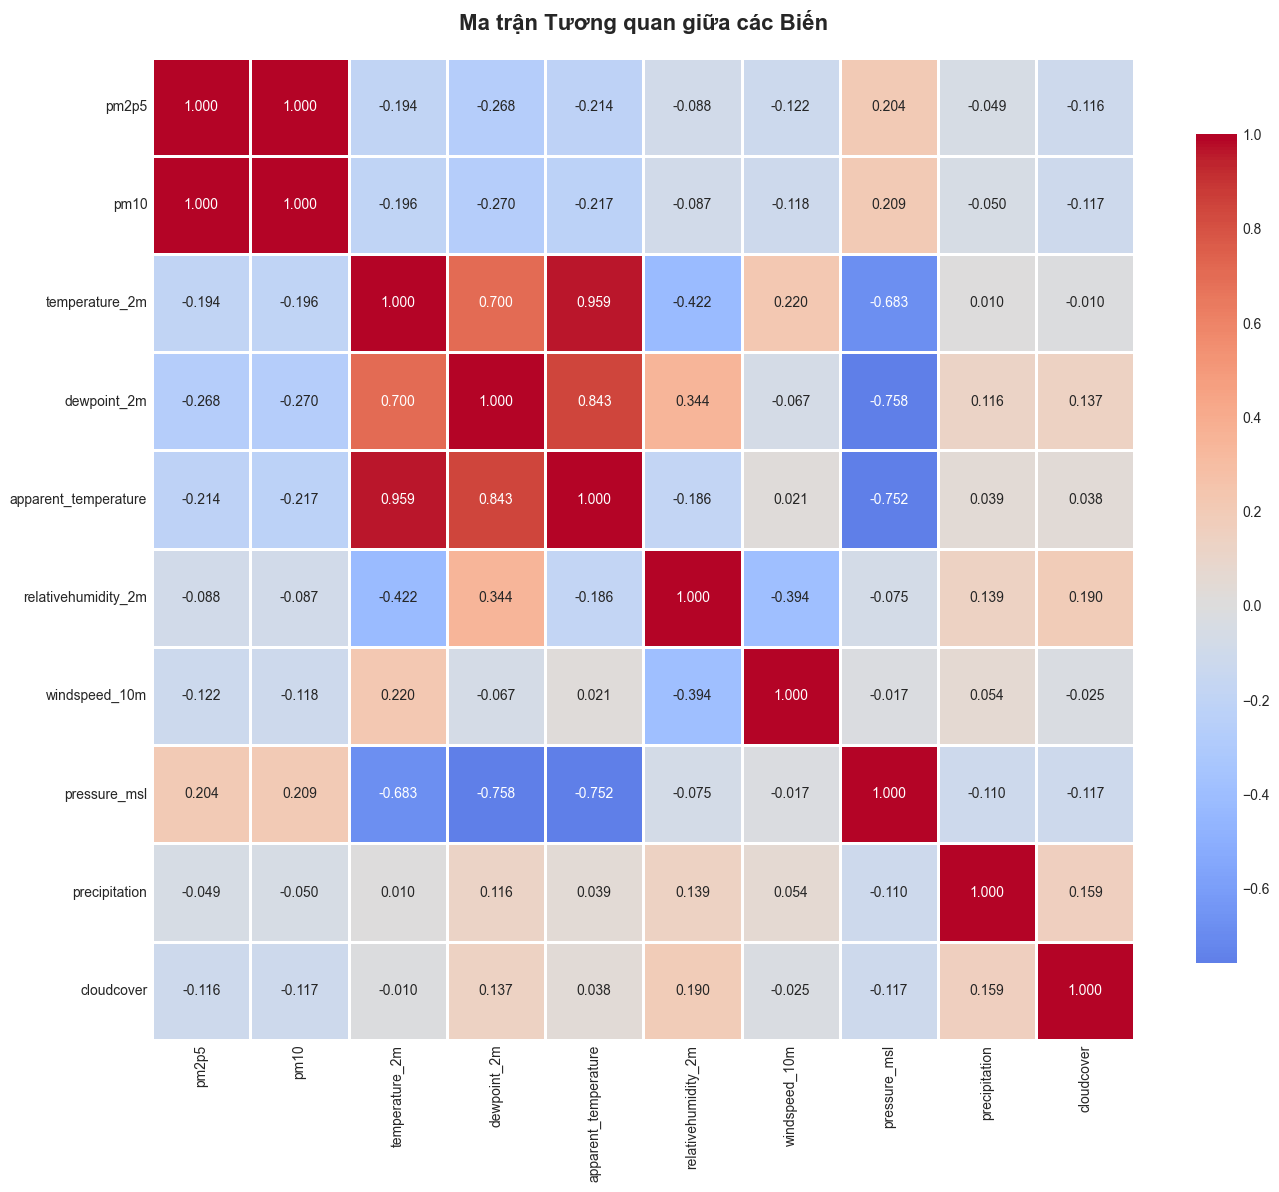

In [75]:
# Ma trận tương quan giữa các biến quan trọng
correlation_vars = ['pm2p5', 'pm10', 'temperature_2m', 'dewpoint_2m', 
                    'apparent_temperature', 'relativehumidity_2m', 
                    'windspeed_10m', 'pressure_msl', 'precipitation', 'cloudcover']

corr_matrix = df[correlation_vars].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Ma trận Tương quan giữa các Biến', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


In [76]:
# Tương quan giữa PM2.5/PM10 với các biến thời tiết
print("=== TƯƠNG QUAN GIỮA PM2.5 VÀ CÁC BIẾN THỜI TIẾT ===\n")
pm25_corr = df[correlation_vars].corr()['pm2p5'].sort_values(ascending=False)
print(pm25_corr)

print("\n=== TƯƠNG QUAN GIỮA PM10 VÀ CÁC BIẾN THỜI TIẾT ===\n")
pm10_corr = df[correlation_vars].corr()['pm10'].sort_values(ascending=False)
print(pm10_corr)


=== TƯƠNG QUAN GIỮA PM2.5 VÀ CÁC BIẾN THỜI TIẾT ===

pm2p5                   1.000000
pm10                    0.999750
pressure_msl            0.204098
precipitation          -0.048948
relativehumidity_2m    -0.087573
cloudcover             -0.115554
windspeed_10m          -0.121821
temperature_2m         -0.193589
apparent_temperature   -0.213769
dewpoint_2m            -0.267962
Name: pm2p5, dtype: float64

=== TƯƠNG QUAN GIỮA PM10 VÀ CÁC BIẾN THỜI TIẾT ===

pm10                    1.000000
pm2p5                   0.999750
pressure_msl            0.208609
precipitation          -0.049798
relativehumidity_2m    -0.086990
cloudcover             -0.116983
windspeed_10m          -0.117902
temperature_2m         -0.196027
apparent_temperature   -0.217097
dewpoint_2m            -0.269955
Name: pm10, dtype: float64


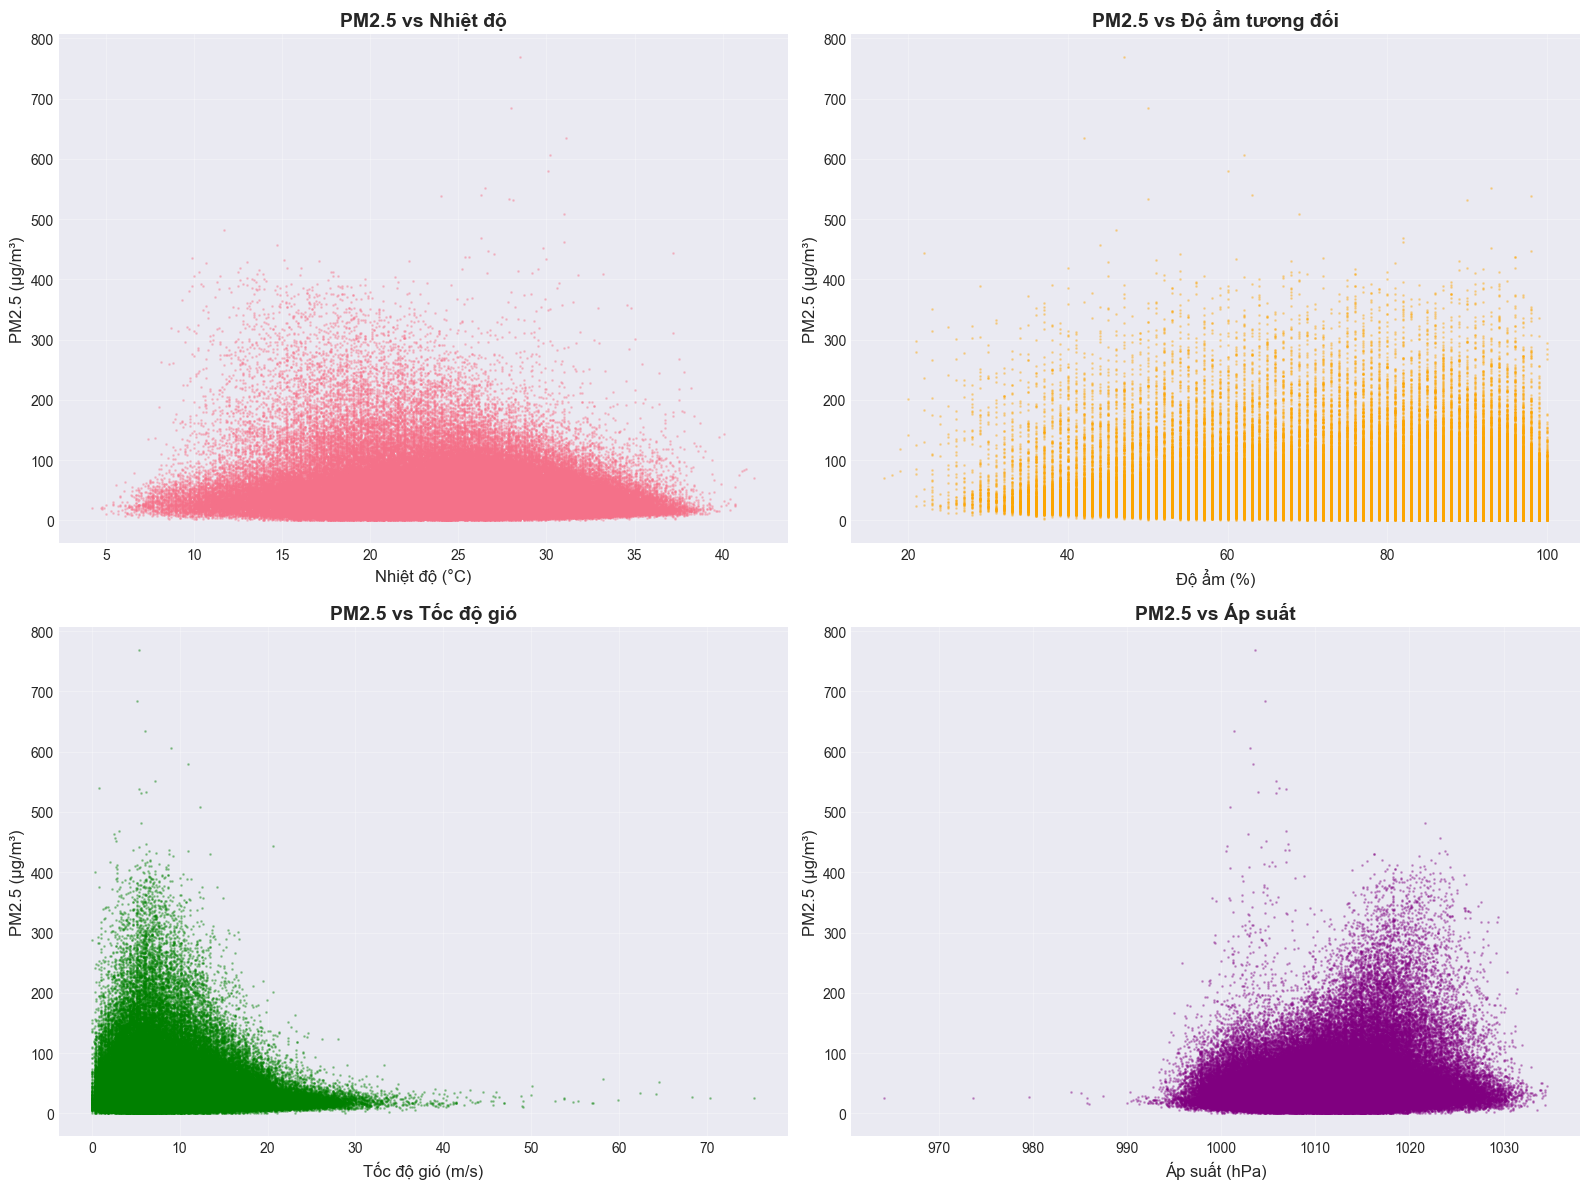

In [77]:
# Scatter plot: PM2.5 vs Nhiệt độ
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# PM2.5 vs Nhiệt độ
axes[0, 0].scatter(df['temperature_2m'], df['pm2p5'], alpha=0.3, s=1)
axes[0, 0].set_title('PM2.5 vs Nhiệt độ', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Nhiệt độ (°C)', fontsize=12)
axes[0, 0].set_ylabel('PM2.5 (μg/m³)', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# PM2.5 vs Độ ẩm
axes[0, 1].scatter(df['relativehumidity_2m'], df['pm2p5'], alpha=0.3, s=1, color='orange')
axes[0, 1].set_title('PM2.5 vs Độ ẩm tương đối', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Độ ẩm (%)', fontsize=12)
axes[0, 1].set_ylabel('PM2.5 (μg/m³)', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# PM2.5 vs Tốc độ gió
axes[1, 0].scatter(df['windspeed_10m'], df['pm2p5'], alpha=0.3, s=1, color='green')
axes[1, 0].set_title('PM2.5 vs Tốc độ gió', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Tốc độ gió (m/s)', fontsize=12)
axes[1, 0].set_ylabel('PM2.5 (μg/m³)', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# PM2.5 vs Áp suất
axes[1, 1].scatter(df['pressure_msl'], df['pm2p5'], alpha=0.3, s=1, color='purple')
axes[1, 1].set_title('PM2.5 vs Áp suất', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Áp suất (hPa)', fontsize=12)
axes[1, 1].set_ylabel('PM2.5 (μg/m³)', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


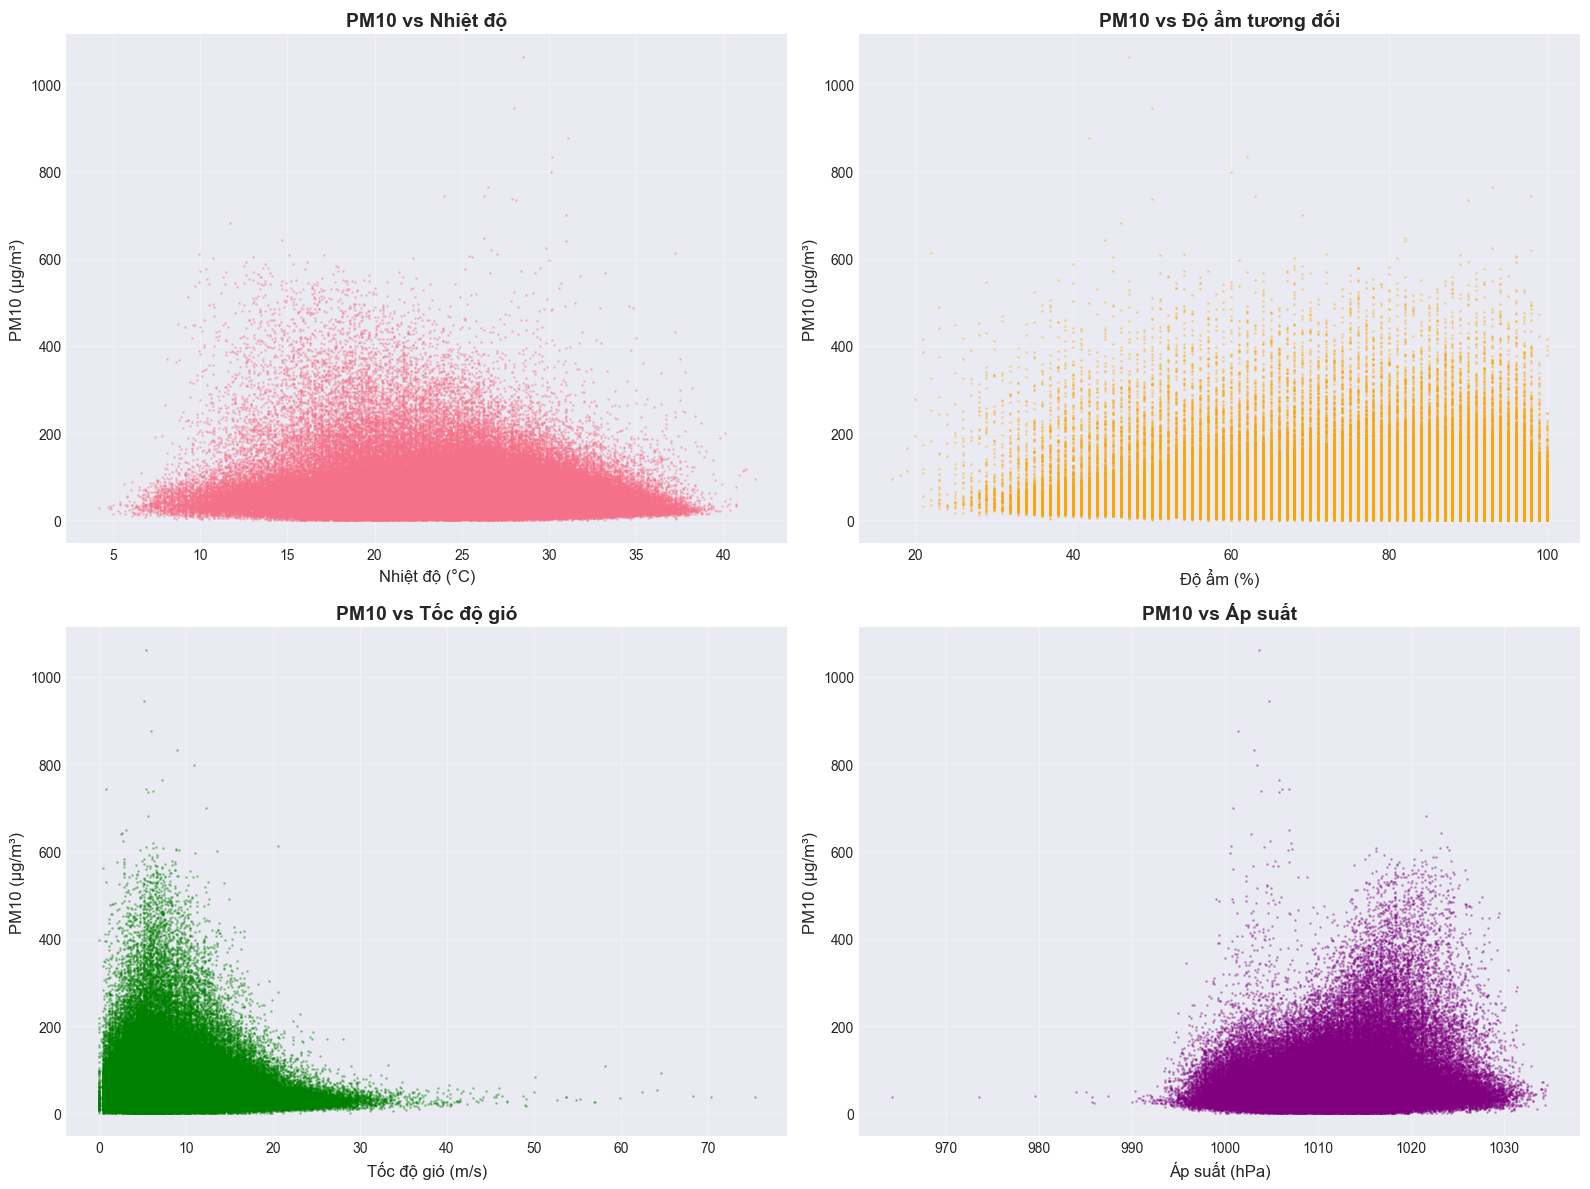

In [78]:
# Scatter plot: PM10 vs các biến thời tiết
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# PM10 vs Nhiệt độ
axes[0, 0].scatter(df['temperature_2m'], df['pm10'], alpha=0.3, s=1)
axes[0, 0].set_title('PM10 vs Nhiệt độ', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Nhiệt độ (°C)', fontsize=12)
axes[0, 0].set_ylabel('PM10 (μg/m³)', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# PM10 vs Độ ẩm
axes[0, 1].scatter(df['relativehumidity_2m'], df['pm10'], alpha=0.3, s=1, color='orange')
axes[0, 1].set_title('PM10 vs Độ ẩm tương đối', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Độ ẩm (%)', fontsize=12)
axes[0, 1].set_ylabel('PM10 (μg/m³)', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# PM10 vs Tốc độ gió
axes[1, 0].scatter(df['windspeed_10m'], df['pm10'], alpha=0.3, s=1, color='green')
axes[1, 0].set_title('PM10 vs Tốc độ gió', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Tốc độ gió (m/s)', fontsize=12)
axes[1, 0].set_ylabel('PM10 (μg/m³)', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# PM10 vs Áp suất
axes[1, 1].scatter(df['pressure_msl'], df['pm10'], alpha=0.3, s=1, color='purple')
axes[1, 1].set_title('PM10 vs Áp suất', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Áp suất (hPa)', fontsize=12)
axes[1, 1].set_ylabel('PM10 (μg/m³)', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 6. Phân tích theo Vị trí địa lý


=== THỐNG KÊ VỀ VỊ TRÍ ĐỊA LÝ ===

Vĩ độ: 9.1833 - 22.4800
Kinh độ: 103.9700 - 109.2197


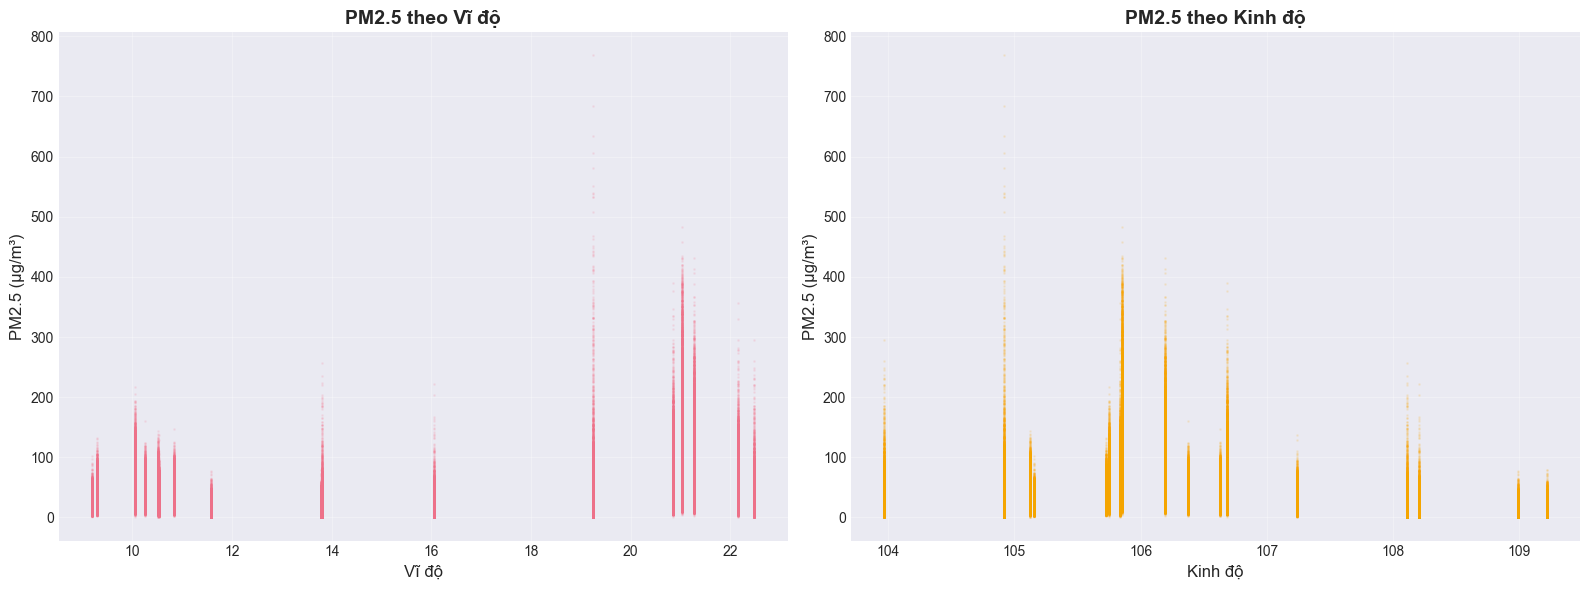

In [79]:
# Phân tích theo vĩ độ và kinh độ
print("=== THỐNG KÊ VỀ VỊ TRÍ ĐỊA LÝ ===\n")
print(f"Vĩ độ: {df['latitude'].min():.4f} - {df['latitude'].max():.4f}")
print(f"Kinh độ: {df['longitude'].min():.4f} - {df['longitude'].max():.4f}")

# PM2.5 và PM10 theo vĩ độ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df['latitude'], df['pm2p5'], alpha=0.1, s=1)
axes[0].set_title('PM2.5 theo Vĩ độ', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Vĩ độ', fontsize=12)
axes[0].set_ylabel('PM2.5 (μg/m³)', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df['longitude'], df['pm2p5'], alpha=0.1, s=1, color='orange')
axes[1].set_title('PM2.5 theo Kinh độ', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Kinh độ', fontsize=12)
axes[1].set_ylabel('PM2.5 (μg/m³)', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 7. Phân tích Outliers và Dữ liệu bất thường


In [80]:
# Xác định outliers sử dụng IQR method cho PM2.5 và PM10
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# PM2.5 outliers
pm25_outliers, pm25_lower, pm25_upper = detect_outliers_iqr(df, 'pm2p5')
print(f"=== OUTLIERS PM2.5 ===")
print(f"Q1: {df['pm2p5'].quantile(0.25):.2f} μg/m³")
print(f"Q3: {df['pm2p5'].quantile(0.75):.2f} μg/m³")
print(f"IQR: {df['pm2p5'].quantile(0.75) - df['pm2p5'].quantile(0.25):.2f} μg/m³")
print(f"Giới hạn dưới: {pm25_lower:.2f} μg/m³")
print(f"Giới hạn trên: {pm25_upper:.2f} μg/m³")
print(f"Số lượng outliers: {len(pm25_outliers):,} ({len(pm25_outliers)/len(df)*100:.2f}%)")

# PM10 outliers
pm10_outliers, pm10_lower, pm10_upper = detect_outliers_iqr(df, 'pm10')
print(f"\n=== OUTLIERS PM10 ===")
print(f"Q1: {df['pm10'].quantile(0.25):.2f} μg/m³")
print(f"Q3: {df['pm10'].quantile(0.75):.2f} μg/m³")
print(f"IQR: {df['pm10'].quantile(0.75) - df['pm10'].quantile(0.25):.2f} μg/m³")
print(f"Giới hạn dưới: {pm10_lower:.2f} μg/m³")
print(f"Giới hạn trên: {pm10_upper:.2f} μg/m³")
print(f"Số lượng outliers: {len(pm10_outliers):,} ({len(pm10_outliers)/len(df)*100:.2f}%)")


=== OUTLIERS PM2.5 ===
Q1: 17.20 μg/m³
Q3: 44.17 μg/m³
IQR: 26.97 μg/m³
Giới hạn dưới: -23.25 μg/m³
Giới hạn trên: 84.62 μg/m³
Số lượng outliers: 23,201 (6.67%)

=== OUTLIERS PM10 ===
Q1: 24.72 μg/m³
Q3: 62.19 μg/m³
IQR: 37.46 μg/m³
Giới hạn dưới: -31.47 μg/m³
Giới hạn trên: 118.38 μg/m³
Số lượng outliers: 23,440 (6.74%)


### 8. Tóm tắt và Kết luận


In [ ]:
# Tóm tắt các phát hiện chính
print("=" * 60)
print("TÓM TẮT EDA - WEATHER & AQI DATASET")
print("=" * 60)

print(f"\n1. TỔNG QUAN DATASET:")
print(f"   - Tổng số quan sát: {df.shape[0]:,}")
print(f"   - Số lượng biến: {df.shape[1]}")
print(f"   - Thời gian: {df['time'].min()} đến {df['time'].max()}")
print(f"   - Số tỉnh/thành phố: {df['province'].nunique()}")

print(f"\n2. CHẤT LƯỢNG KHÔNG KHÍ (AQI):")
print(f"   - PM2.5 trung bình: {df['pm2p5'].mean():.2f} μg/m³")
print(f"   - PM2.5 min: {df['pm2p5'].min():.2f} μg/m³, max: {df['pm2p5'].max():.2f} μg/m³")
print(f"   - PM10 trung bình: {df['pm10'].mean():.2f} μg/m³")
print(f"   - PM10 min: {df['pm10'].min():.2f} μg/m³, max: {df['pm10'].max():.2f} μg/m³")
print(f"   - Tỉnh có PM2.5 cao nhất: {df.groupby('province')['pm2p5'].mean().idxmax()} ({df.groupby('province')['pm2p5'].mean().max():.2f} μg/m³)")
print(f"   - Tỉnh có PM2.5 thấp nhất: {df.groupby('province')['pm2p5'].mean().idxmin()} ({df.groupby('province')['pm2p5'].mean().min():.2f} μg/m³)")

print(f"\n3. THỜI TIẾT:")
print(f"   - Nhiệt độ trung bình: {df['temperature_2m'].mean():.2f}°C")
print(f"   - Độ ẩm trung bình: {df['relativehumidity_2m'].mean():.2f}%")
print(f"   - Tốc độ gió trung bình: {df['windspeed_10m'].mean():.2f} m/s")
print(f"   - Áp suất trung bình: {df['pressure_msl'].mean():.2f} hPa")

print(f"\n4. TƯƠNG QUAN:")
corr_pm25_temp = df['pm2p5'].corr(df['temperature_2m'])
corr_pm25_humidity = df['pm2p5'].corr(df['relativehumidity_2m'])
corr_pm25_wind = df['pm2p5'].corr(df['windspeed_10m'])
corr_pm25_pm10 = df['pm2p5'].corr(df['pm10'])
print(f"   - PM2.5 vs PM10: {corr_pm25_pm10:.3f} (tương quan rất cao)")
print(f"   - PM2.5 vs Nhiệt độ: {corr_pm25_temp:.3f}")
print(f"   - PM2.5 vs Độ ẩm: {corr_pm25_humidity:.3f}")
print(f"   - PM2.5 vs Tốc độ gió: {corr_pm25_wind:.3f}")

print(f"\n5. GIÁ TRỊ THIẾU:")
missing_count = df.isnull().sum().sum()
print(f"   - Tổng số giá trị thiếu: {missing_count:,}")
print(f"   - Tỷ lệ: {missing_count/(df.shape[0]*df.shape[1])*100:.2f}%")

print(f"\n6. PHẠM VI GIÁ TRỊ:")
print(f"   - PM2.5: {df['pm2p5'].min():.2f} - {df['pm2p5'].max():.2f} μg/m³")
print(f"   - PM10: {df['pm10'].min():.2f} - {df['pm10'].max():.2f} μg/m³")
print(f"   - Nhiệt độ: {df['temperature_2m'].min():.2f} - {df['temperature_2m'].max():.2f}°C")

print("\n" + "=" * 60)


TÓM TẮT EDA - WEATHER & AQI DATASET

1. TỔNG QUAN DATASET:
   - Tổng số quan sát: 347,752
   - Số lượng biến: 43
   - Thời gian: 2018-01-01 00:00:00 đến 2024-12-31 21:00:00
   - Số tỉnh/thành phố: 17

2. CHẤT LƯỢNG KHÔNG KHÍ (AQI):
   - PM2.5 trung bình: 36.75 μg/m³
   - PM2.5 min: 0.00 μg/m³, max: 768.13 μg/m³
   - PM10 trung bình: 51.93 μg/m³
   - PM10 min: 0.00 μg/m³, max: 1060.84 μg/m³
   - Tỉnh có PM2.5 cao nhất: Ha_Noi (88.50 μg/m³)
   - Tỉnh có PM2.5 thấp nhất: Binh_Dinh (15.85 μg/m³)

3. THỜI TIẾT:
   - Nhiệt độ trung bình: 25.56°C
   - Độ ẩm trung bình: 80.48%
   - Tốc độ gió trung bình: 9.14 m/s
   - Áp suất trung bình: 1010.43 hPa

4. TƯƠNG QUAN:
   - PM2.5 vs PM10: 1.000 (tương quan rất cao)
   - PM2.5 vs Nhiệt độ: -0.194
   - PM2.5 vs Độ ẩm: -0.088
   - PM2.5 vs Tốc độ gió: -0.122

5. GIÁ TRỊ THIẾU:
   - Tổng số giá trị thiếu: 4,520,776
   - Tỷ lệ: 30.23%

6. PHẠM VI GIÁ TRỊ:
   - PM2.5: 0.00 - 768.13 μg/m³
   - PM10: 0.00 - 1060.84 μg/m³
   - Nhiệt độ: 4.20 - 41.80°C



: 

## Kết luận

Dựa trên phân tích EDA, chúng ta có thể rút ra một số kết luận:

1. **Về dữ liệu**: 
   - Dataset có quy mô lớn với hơn 347,000 quan sát từ 17 tỉnh/thành phố khác nhau
   - Dữ liệu trải dài từ năm 2018 đến 2024 (7 năm)
   - Có khoảng 30% giá trị thiếu, chủ yếu ở các cột nhiệt độ ở độ cao khác nhau và một số biến thời tiết khác

2. **Về chất lượng không khí (AQI)**: 
   - PM2.5 trung bình: ~36.75 μg/m³ (phạm vi: 0 - 768 μg/m³)
   - PM10 trung bình: ~51.93 μg/m³ (phạm vi: 0 - 1060 μg/m³)
   - PM2.5 và PM10 có tương quan rất cao (0.999), cho thấy chúng có xu hướng biến đổi cùng nhau
   - Hà Nội có PM2.5 cao nhất, Bình Định có PM2.5 thấp nhất
   - Có nhiều outliers, đặc biệt là các giá trị rất cao

3. **Về thời tiết**: 
   - Nhiệt độ trung bình: ~25.56°C
   - Độ ẩm trung bình: ~80.48% (khá cao, phù hợp với khí hậu nhiệt đới)
   - Tốc độ gió trung bình: ~9.14 m/s
   - Áp suất trung bình: ~1010.43 hPa

4. **Mối quan hệ giữa thời tiết và AQI**:
   - PM2.5 có tương quan âm yếu với nhiệt độ (-0.194), độ ẩm (-0.088), và tốc độ gió (-0.122)
   - Tốc độ gió cao hơn có xu hướng làm giảm nồng độ PM (phân tán chất ô nhiễm)
   - Nhiệt độ thấp hơn có xu hướng liên quan đến PM cao hơn (có thể do nghịch nhiệt)

5. **Xu hướng thời gian**: 
   - Có thể quan sát được xu hướng theo năm, tháng, và giờ trong ngày
   - Cần phân tích sâu hơn để xác định mùa và thời điểm có AQI cao nhất

6. **Hướng phát triển tiếp theo**:
   - Làm sạch dữ liệu (xử lý missing values, outliers)
   - Feature engineering (tạo biến mùa, biến thời gian, biến tương tác)
   - Phân tích sâu hơn về xu hướng thời gian và theo địa điểm
   - Xây dựng mô hình dự đoán AQI dựa trên thời tiết và các yếu tố khác
